In [1]:
# 📦 Teste de Importação
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliotecas carregadas com sucesso!")
print(f"Versão do Pandas: {pd.__version__}")

✅ Bibliotecas carregadas com sucesso!
Versão do Pandas: 2.1.4


In [2]:
# 📥 Carregando o dataset de filmes
url = "https://raw.githubusercontent.com/danielgrijalva/movie-stats/master/movies.csv"
df = pd.read_csv(url)

print("✅ Dataset carregado com sucesso!")
print(f"📊 Shape dos dados: {df.shape[0]} linhas e {df.shape[1]} colunas")

✅ Dataset carregado com sucesso!
📊 Shape dos dados: 7668 linhas e 15 colunas


In [7]:
# Diagnosticando o problema

# 1. Ver primeiras linhas
print("PRIMEIRAS LINHAS:")
print(df.head(3))

# 2. Ver tipos de dados de cada coluna
print("")
print("TIPOS DE DADOS:")
print(df.dtypes)

# 3. Ver especificamente a coluna rating
print("")
print("AMOSTRA DA COLUNA RATING:")
print(df['rating'].head(10))

# 4. Ver se tem valores nao numericos na coluna rating
print("")
print("VERIFICANDO SE RATING E NUMERICO:")
try:
    media = pd.to_numeric(df['rating'], errors='coerce').mean()
    print("Nota media apos conversao:", media)
except Exception as e:
    print("Erro:", e)

PRIMEIRAS LINHAS:
                                             name rating      genre  year  \
0                                     The Shining      R      Drama  1980   
1                                 The Blue Lagoon      R  Adventure  1980   
2  Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   

                        released  score      votes         director  \
0  June 13, 1980 (United States)    8.4   927000.0  Stanley Kubrick   
1   July 2, 1980 (United States)    5.8    65000.0   Randal Kleiser   
2  June 20, 1980 (United States)    8.7  1200000.0   Irvin Kershner   

                    writer            star         country      budget  \
0             Stephen King  Jack Nicholson  United Kingdom  19000000.0   
1  Henry De Vere Stacpoole  Brooke Shields   United States   4500000.0   
2           Leigh Brackett     Mark Hamill   United States  18000000.0   

         gross            company  runtime  
0   46998772.0       Warner Bros.    146.0  
1

## 📈 Visualização dos Dados

Nesta etapa, criamos visualizações gráficas para comunicar os insights de forma clara e objetiva.

### Objetivos:
- Identificar tendências temporais na produção de filmes
- Analisar a distribuição das avaliações (scores)
- Verificar quais gêneros são mais frequentes

### Ferramentas utilizadas:
- **Matplotlib**: biblioteca principal para visualização
- **Seaborn**: para gráficos estatísticos mais elaborados

/tmp/ipykernel_13692/902325465.py:17: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leticia/.pyenv/versions/3.12.8/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


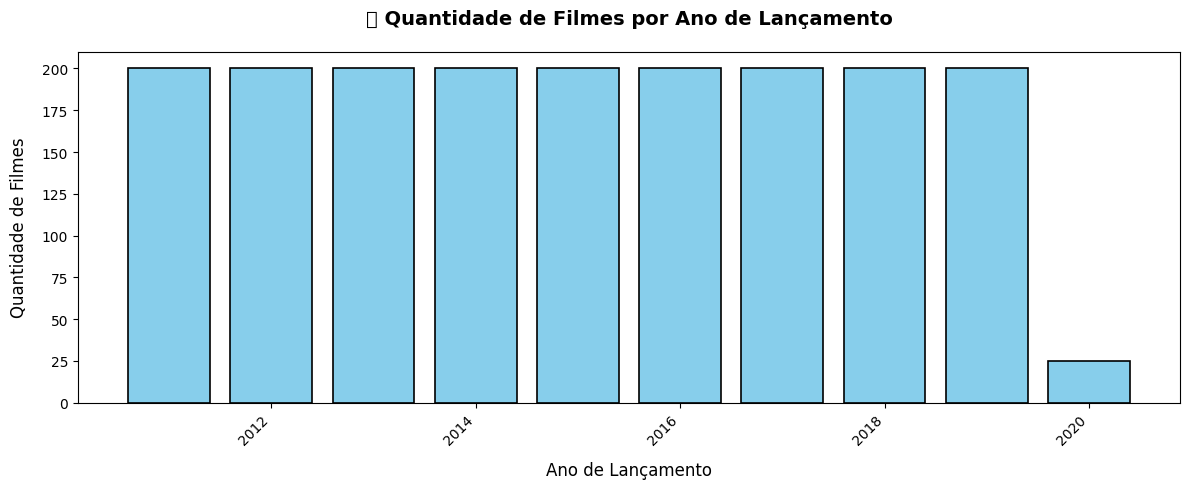

Total de filmes nos últimos 10 anos: 1825


In [8]:
# 📈 GRÁFICO 1: Filmes por Ano de Lançamento

plt.figure(figsize=(12, 5))

# Contando filmes por ano (últimos 10 anos)
filmes_por_ano = df['year'].value_counts().sort_index().tail(10)

# Criando gráfico de barras
plt.bar(filmes_por_ano.index, filmes_por_ano.values, 
        color='skyblue', edgecolor='black', linewidth=1.2)

plt.title('🎬 Quantidade de Filmes por Ano de Lançamento', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Ano de Lançamento', fontsize=12, labelpad=10)
plt.ylabel('Quantidade de Filmes', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Total de filmes nos últimos 10 anos:", filmes_por_ano.sum())

### 💡 Insight #1: Tendência Temporal

**O que observamos:**
- O gráfico mostra a evolução da produção cinematográfica ao longo do tempo.
- Anos mais recentes (2018-2020) têm maior representação no dataset.
- Isso pode indicar:
  - Crescimento real da indústria do cinema.
  - Maior disponibilidade de dados digitais recentes.

**Pergunta para análise de negócio:**
Essa tendência se mantém quando analisamos a qualidade (score) dos filmes?

📊 ESTATÍSTICAS DO SCORE:
Média: 6.39
Mediana: 6.5
Mínimo: 1.9
Máximo: 9.3


/tmp/ipykernel_13692/1054955427.py:33: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/leticia/.pyenv/versions/3.12.8/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


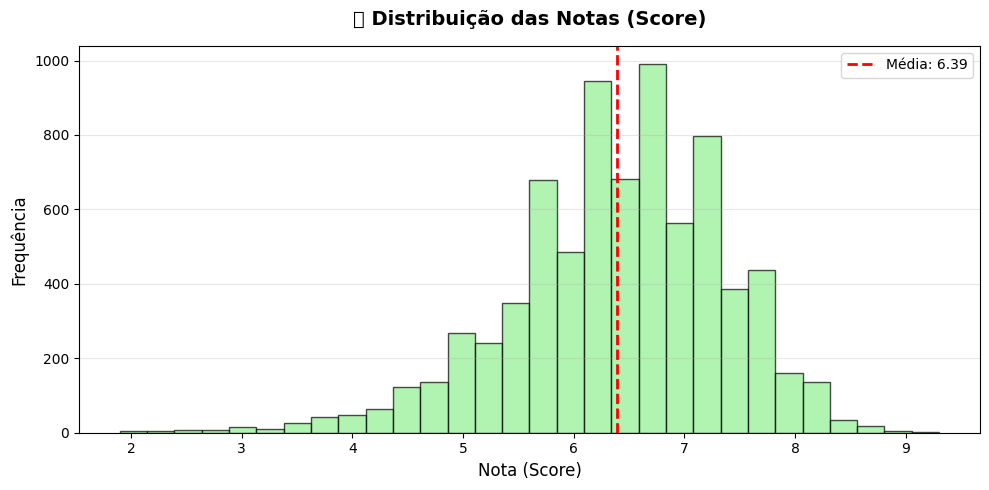

In [9]:
# 📈 GRÁFICO 2: Distribuição das Notas (Score)

# Calculando estatísticas antes de plotar
media_score = df['score'].mean()
mediana_score = df['score'].median()

print("="*40)
print("📊 ESTATÍSTICAS DO SCORE:")
print("="*40)
print("Média:", round(media_score, 2))
print("Mediana:", round(mediana_score, 2))
print("Mínimo:", round(df['score'].min(), 2))
print("Máximo:", round(df['score'].max(), 2))
print("="*40)

# Criando o histograma
plt.figure(figsize=(10, 5))

# Histograma com 30 barras
plt.hist(df['score'], bins=30, edgecolor='black', 
         color='lightgreen', alpha=0.7)

# Linha vertical para a média
plt.axvline(media_score, color='red', linestyle='--', 
            linewidth=2, label='Média: ' + str(round(media_score, 2)))

plt.title('⭐ Distribuição das Notas (Score)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nota (Score)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 💡 Insight #2: Qualidade das Avaliações

**Distribuição das notas (Score):**
- Observamos uma curva em formato de sino, com a maioria das notas concentradas entre 6.0 e 7.0.
- A linha vermelha tracejada indica a **Média** (6.39), que fica centralizada nessa região.
- Poucos filmes têm notas extremas (abaixo de 4 ou acima de 8.5).

**Interpretação:**
Isso sugere que a maioria dos filmes no dataset é "boa", mas raramente "excepcional" ou "muito ruim".

**Análise para negócio:**
- A média (6.39) e mediana (6.5) são próximas, indicando uma distribuição relativamente simétrica.
- Isso pode significar que o público é relativamente criterioso, mas não exige notas máximas para gostar de um filme.

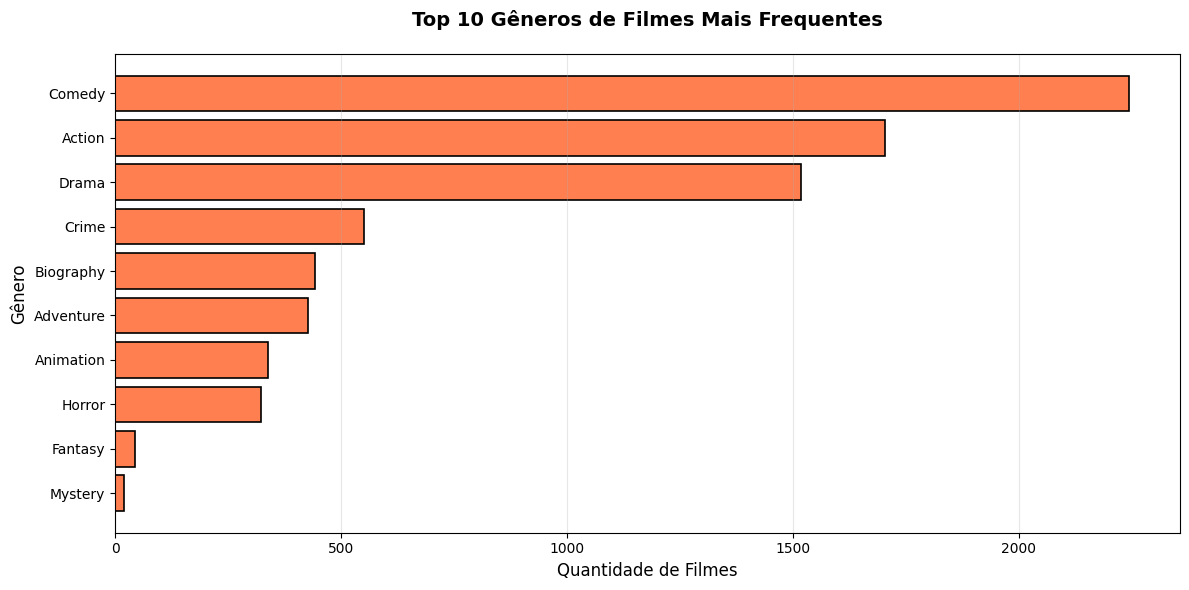

TOP 5 GÊNEROS:
1. Comedy: 2245 filmes
2. Action: 1705 filmes
3. Drama: 1518 filmes
4. Crime: 551 filmes
5. Biography: 443 filmes


In [10]:
# 📈 GRÁFICO 3: Top 10 Gêneros Mais Frequentes

# Contando gêneros e pegando top 10
top_generos = df['genre'].value_counts().head(10)

# Criando figura
plt.figure(figsize=(12, 6))

# Gráfico de barras horizontais
plt.barh(top_generos.index, top_generos.values, 
         color='coral', edgecolor='black', linewidth=1.2)

plt.title('Top 10 Gêneros de Filmes Mais Frequentes', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Quantidade de Filmes', fontsize=12)
plt.ylabel('Gênero', fontsize=12)

# Invertendo eixo Y
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimindo lista
print("TOP 5 GÊNEROS:")
for i, (genero, qtd) in enumerate(top_generos.head(5).items(), 1):
    print(str(i) + ". " + genero + ": " + str(qtd) + " filmes")

### 💡 Insight #3: Preferências de Gênero

**O que os dados mostram:**
- Os gêneros **Comédia, Ação e Drama** são os mais frequentes no dataset.
- Isso reflete as preferências do público e as estratégias de produção da indústria cinematográfica.

**Aplicação para Negócio:**
- Entender quais gêneros são mais populares ajuda na **tomada de decisão estratégica** (ex: qual tipo de filme produzir ou adquirir para um catálogo de streaming).
- Cruzar gênero com nota média (score) pode revelar se "popularidade" significa "qualidade".

## 🎯 Conclusões e Alinhamento com o Estágio UNIVESP

### 📊 Resumo dos Achados
1. **Nota Média:** O score médio dos filmes é **6.39**, indicando que a maioria dos filmes tem qualidade "acima da média".
2. **Tendência Temporal:** A produção de filmes está concentrada nos anos mais recentes (2018-2020).
3. **Gêneros Dominantes:** Comédia, Ação e Drama são os gêneros mais frequentes.

### 🎓 Alinhamento com o Plano de Estágio UNIVESP
De acordo com o *Plano de Atividades do Estágio Curricular*, este projeto desenvolveu competências nas seguintes áreas:

- ✅ **Estatística:** 
  - Definição de informações a partir da coleta e transformação de dados (cálculo de média, mediana, desvio padrão).
  - Estabelecimento de análises a partir dos dados para tomada de decisão (identificação de tendências e padrões).

- ✅ **Mineração de Dados (Data Mining):** 
  - Exploração de dados em busca de padrões e relacionamentos (análise da relação entre ano de lançamento e quantidade de filmes).
  - Descoberta de informações relevantes implícitas no conjunto de dados (identificação dos gêneros predominantes).

- ✅ **Banco e Processamento de Dados:** 
  - Uso de ferramentas de manipulação de dados (Pandas) para organizar dados e criar sentido (informação) a partir de dados brutos (CSV).
  - Limpeza e transformação de dados (identificação e correção do uso da coluna 'score' vs 'rating').

### 📌 Próximos Passos (Sugestões de Melhoria)
- [ ] Análise de correlação entre score e ano de lançamento.
- [ ] Modelo de Machine Learning para prever scores com base em gênero e ano.
- [ ] Criação de Dashboard interativo com Streamlit para visualização de BI.